# Student Depression and Lifestyle
Rakhmettula Ramazan<br>
The original dataset is available at the link: https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data

## Data Preparation and Exploratory Data Analysis (EDA)

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

### Data Inspection

Data loading.

In [2]:
df = pd.read_csv('student_lifestyle_100k.csv')

Overview of the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


First 5 rows of the dataset.

In [4]:
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Last 5 rows of the dataset.

In [5]:
df.tail()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
99995,100996,24,Female,Medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,Arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,Engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,Engineering,3.61,6.1,4.8,4.9,116,4,False
99999,101000,24,Female,Medical,2.10,7.9,3.5,4.0,79,4,False


Number of rows and columns in the dataset.

In [6]:
df.shape

(100000, 11)

Data type of each variable.

In [7]:
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
Department,object
CGPA,float64
Sleep_Duration,float64
Study_Hours,float64
Social_Media_Hours,float64
Physical_Activity,int64
Stress_Level,int64


Descritpive statistics of numeric variables.

In [8]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


Number of missing values.

In [9]:
df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0


Number of duplicated records.

In [10]:
df.duplicated().sum()

np.int64(0)

### Data Cleaning

Renaming 'Sleep_Duration' variable to 'Sleep_Hours' for convenience and 'Physical_Activity' to 'Physical_Activity_Weekly' for better understanding.

In [11]:
df.rename(columns={'Sleep_Duration': 'Sleep_Hours', 'Physical_Activity': 'Physical_Activity_Weekly'}, inplace=True)

Creating new feature for further analysis.

In [12]:
df['Physical_Activity_Daily'] = (df['Physical_Activity_Weekly'] / 7).round(1)

Converting logical data to numeric.

In [13]:
df['Depression'] = df['Depression'].astype(int)

### Visualisation

/tmp/ipython-input-2132065556.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Depression', palette='viridis')


Text(0, 0.5, 'Count')

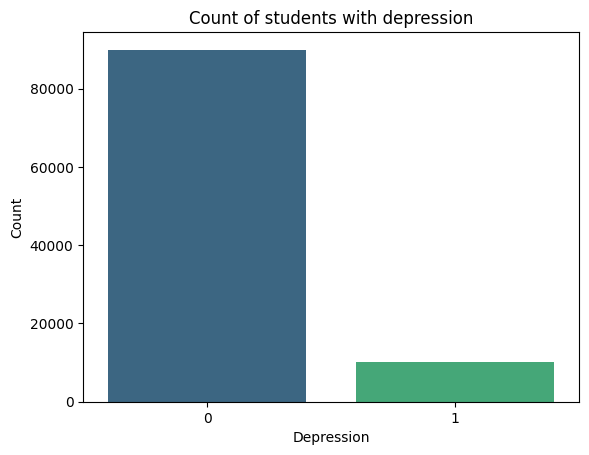

In [14]:
sns.countplot(data=df, x='Depression', palette='viridis')
plt.title('Count of students with depression')
plt.xlabel('Depression')
plt.ylabel('Count')

---

Text(0, 0.5, 'Frequency')

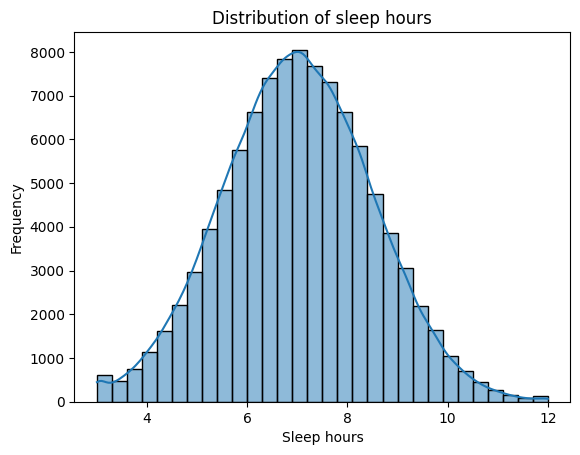

In [15]:
sns.histplot(df['Sleep_Hours'], kde=True, bins=30)
plt.title("Distribution of sleep hours")
plt.xlabel("Sleep hours")
plt.ylabel("Frequency")

---

/tmp/ipython-input-2585503656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Stress_Level', palette='viridis')


Text(0, 0.5, 'Frequency')

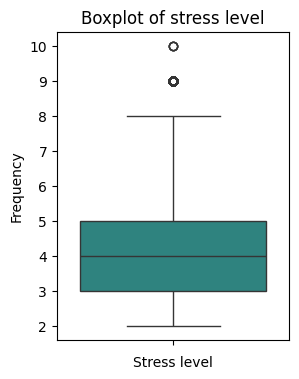

In [16]:
plt.figure(figsize=(3, 4))
sns.boxplot(data=df, y='Stress_Level', palette='viridis')
plt.title('Boxplot of stress level')
plt.xlabel('Stress level')
plt.ylabel('Frequency')

---

/tmp/ipython-input-534539489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


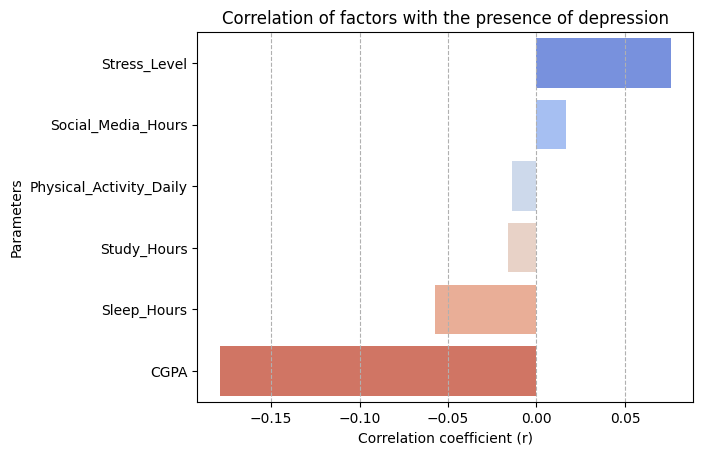

In [17]:
features = ['CGPA', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity_Daily', 'Stress_Level']

correlations = df[features + ['Depression']].corr()['Depression'].drop('Depression').sort_values(ascending=False)

sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.title('Correlation of factors with the presence of depression')
plt.xlabel('Correlation coefficient (r)')
plt.ylabel('Parameters')
plt.grid(axis='x', linestyle='--')

### Initial Insight

As we can observe, stress level has the highest correlation to likeability to have depression, while CGPA has negative which suggests that students with higher CGPA tend to not have depression. Though we cant heavily rely on the stress level parameter since it was self chosen by students and may not be objective, so we should prefer social media hours.

## Hypothesis Testing

Significance level α = 0.05

### One-sample t-test

*Is 2.9 a mean value of CGPA?*

Hypotheses:
- $H_{0}$: μ = 2.9
- $H_{1}$: μ ≠ 2.9

In [18]:
t, p = stats.ttest_1samp(df['CGPA'], 2.9)

print(f"One-sample t-test:\nt = {np.round(t, 3)}\np = {np.round(p, 4)}")

One-sample t-test:
t = -1.001
p = 0.317


- **t-statistics** tells that the sample mean is slightly less than suggested mean value 2,9.
- **$p > α$**, suggesting that there is no genuine difference in CGPA means occured. The probability of this difference that we got is not significant enough not to call it a coincidence. Thus, we fail to reject $H_{0}$, mean of the CGPA is not differ from 2,9.

### Two-sample t-test

#### Levene's test

*Is there a difference in the variances of daily physical activity minutes between students diagnosed with depression and those who are not?*

Hypotheses:
- $H_{0}$: Variances are the same
- $H_{1}$: Variances are different

In [19]:
group1 = df[df['Depression'] == True]['Physical_Activity_Daily']
group2 = df[df['Depression'] == False]['Physical_Activity_Daily']

stat, p_levene = stats.levene(group1, group2)

print(f"Levene’s test p-value: {p}")

Levene’s test p-value: 0.3169655342533539


**p > 0.05**: The variances in daily physical activity minutes are different between people with and without depression.

Hence, Welch test need to be used due to its stability and fairness, it will consider true variances without trying to equalize variances.

---

*Is there a statistically significant difference in the mean of daily minutes of physical activities between students with depression and those without depression?*

Hypotheses:
- $H_{0}$: $μ_{1}$ = $μ_{2}$, mean minutes of daily physical activities are equal between those who have depression and do not have depression.
- $H_{1}$: $μ_{1}$ ≠ $μ_{2}$, mean minutes of daily physical activities are different between those who have depression and do not have depression.

In [20]:
t, p = stats.ttest_ind(group1, group2, equal_var=False)

print(f'Two-sample t-test:\nt = {np.round(t, 4)}\np = {p}')

Two-sample t-test:
t = -4.3837
p = 1.176418925180479e-05


- **t-statistics** is less than 0, suggesting a difference between two mean values where mean minutes of physical activities who do not have depression is greater.
- **$p < α$**, suggesting that $H_{0}$ needs to be rejected. We can say that depression does affect physical activities.

### Paired t-test

*Is there a statistically significant difference between the means of hours students spend on study and the hours spent on social media?*

Hypotheses:
- $H_{0}$: $μ_{1}$ = $μ_{2}$, there is no significant difference between the mean study hours and mean hours spent in social media.
- $H_{1}$: $μ_{1}$ ≠ $μ_{2}$, there is significant difference between the mean study hours and mean hours spent in social media.

In [21]:
t, p = stats.ttest_rel(df['Study_Hours'], df['Social_Media_Hours'])

print(f'Paired t-test results:\nt = {np.round(t, 3)}\np = {p}')

Paired t-test results:
t = 128.999
p = 0.0


- **t-statistic** is much more greater than 0, indicating large difference between means where study hours mean is greater.
- **$p < α$** suggests that the difference is statistically significant to be just a coincidence and $H_{0}$ needs to be rejected.

It can be said that students tend to spend much more hours into studying rather then on social media.

### Correlation analysis

*Is there a significant linear/monotonic relationship between the number of sleep hours and the time spent on social media?*

Hypotheses:
- $H_{0}$: $r = 0$, there is no linear/monotonic relationship between study hours and hours spent on social media.
- $H_{1}$: $r ≠ 0$, there is linear/monotonic relationship between study hours and hours spent on social media.

In [22]:
r_pear, p_pear = stats.pearsonr(df['Sleep_Hours'], df['Social_Media_Hours'])

print(f'Pearson Correlation:\nr = {np.round(r_pear, 4)}\np = {p}')

Pearson Correlation:
r = -0.003
p = 0.0


In [23]:
r_spear, p_spear = stats.spearmanr(df['Sleep_Hours'], df['Social_Media_Hours'])

print(f'Spearman Correlation:\nr = {np.round(r_spear, 4)}\np = {p}')

Spearman Correlation:
r = -0.0031
p = 0.0


- **$r_{p}$ = -0.003**, that is very close to zero. It means there is almost no linear correlation between these two features.
- **$r_{s}$ = -0.0031**, that is also very close to 0, suggesting that there is almost no monotonic correlation.
- **$p < α$**, indicating that results that we have are signifacant to say it is not a coincidence and $H_{0}$ needs to be rejected.

However, $H_{0}$ suggests that the is no correlation, and in fact the -0.0031 value have no practical meaning and consider as no correlation at all, but, the p-value tells conversally because of large dataset. Because of 100,000 records even small correlation can be consider as significant.

Pearson test is looking for linear correlation, while Spearman test is looking for monotonic correlation. Spearman is robust to outliers and thus show more precise result in this case. Even so, the difference is invisible.

### One-way ANOVA

*Is there a statistically significant difference in the CGPA between students in different departments?*

Hypotheses:
- $H_{0}$: $\mu_{Science} = \mu_{Eng} = \mu_{Med} = \mu_{Arts} = \mu_{Bus}$, the mean CGPA is the same across all five departments.
- $H_{1}$: $\mu_{Science} ≠ \mu_{Eng} ≠ \mu_{Med} ≠ \mu_{Arts} ≠ \mu_{Bus}$, the mean CGPA differs at least on 1 department.

In [24]:
depts = df['Department'].unique()
groups = [df[df['Department'] == d]['CGPA'] for d in depts]

f, p = stats.f_oneway(*groups)

print(f'One-way ANOVA:\nF = {np.round(f, 3)}\np = {np.round(p, 3)}')

One-way ANOVA:
F = 0.467
p = 0.76


- **F-statistic** is a relatively small number, indicating that mean of grades are consistent across all departments and roughly the same as random variation of grades within students.
- **p > α**, means null hypothesis is fails to be rejected, suggesting that there is no significant difference between departments CGPA and there is no objectively hard or easy to study departments.

## Regression Analysis

### Simple Linear Regression

In [25]:
x = df[['Study_Hours']]
y = df['CGPA']

model_simple = LinearRegression()
model_simple.fit(x, y)

intercept = model_simple.intercept_
slope = model_simple.coef_[0]
r_sq = model_simple.score(x, y)

print(f'Simple Linear Regression')
print(f'Intercept = {np.round(intercept, 3)}')
print(f'Slope = {np.round(slope, 3)}')
print(f'R-squared = {np.round(r_sq, 3)}')

Simple Linear Regression
Intercept = 2.777
Slope = 0.027
R-squared = 0.01


- **Intercept:** If a student studies 0 hours, their predicted CGPA is 2,77.
- **Slope:** For every one hour increase in study time per day, the CGPA is expected to increase by 0.027 points.
- **Goodness of fit ($R^2$)**: The $R^2$ value is very low (0.01), meaning that study hours explain only 1% of the variation in CGPA. It shows that study hours alone are a poor predictor of grades.

### Multiple Linear Regression

In [26]:
x = df[['Study_Hours', 'Sleep_Hours', 'Social_Media_Hours']]
y = df['Stress_Level']

model_multi = LinearRegression()
model_multi.fit(x, y)

intercept = model_multi.intercept_
slopes = model_multi.coef_
r_squared = model_multi.score(x, y)

n = x.shape[0]
p = x.shape[1]
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f'Multiple Linear Regression')
print(f'Intercept = {np.round(intercept, 3)}')
print(f'Coefficients:\n\tStudy = {np.round(slopes[0], 3)}\n\tSleep = {np.round(slopes[1], 3)}\n\tSocial = {np.round(slopes[2], 3)}')
print(f'R-squared = {np.round(r_squared, 3)}')
print(f'Adjusted R-squared = {np.round(adj_r_squared, 3)}')

Multiple Linear Regression
Intercept = 5.968
Coefficients:
	Study = 0.007
	Sleep = -0.267
	Social = 0.001
R-squared = 0.079
Adjusted R-squared = 0.079


- **Coefficients:**
  Holds other factors constant.
  1. Study Hours: Each extra study hour adds 0.007 to Stress Level.
  2. Sleep Hours: Each extra hour of sleep reduces 0.267 from Stress Level.
  3. Social Media Hours: Each extra hour of social media usage adds a tiny 0.001 to Stress Level.
- **$R^2$ vs Adjusted $R^2$:** The values are identical (0.079), indicating that these 3 predictors are meaningful and the model is not penalize for irrelevant variables, but the total predictive power remains is low and explains only about 8% of the variances in Stress Level.
- **Limitations:** The model only explains about 8% of the variance in Stress Level. It can be claimed that stress level is likely driven by factors not included in this dataset or numbers are do not represents real world.